# Analyzer — Vulnerabilidades en `pallets-eco`

Notebook de análisis sobre el dataset generado por el Miner (`data/processed/`).

**Pregunta guía:** ¿dónde se concentra el riesgo de seguridad en la organización y qué parte es realmente accionable?

Fuentes: **CodeQL** (vulnerabilidades en el código propio) y **Grype** (vulnerabilidades conocidas en dependencias, a partir de SBOM de Syft).

Antes de ejecutar: `miner scan`, `miner grype` y `python -m miner.dataset_builder`.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analyzer.utils.data_loader import (
    GRYPE_SEVERITY_ORDER,
    analysis_dir,
    load_dataset,
    load_repositories,
)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 70)

df = load_dataset()
repos = load_repositories()
codeql = df[df["source"] == "codeql"]
grype = df[df["source"] == "grype"]

OUT = analysis_dir()          # data/processed/analysis/ (entrada del Visualizer)
summary = {}                  # métricas clave que se exportan al final
print(f"{len(df)} hallazgos | {len(repos)} repositorios | CodeQL: {len(codeql)} | Grype: {len(grype)}")

386 hallazgos | 30 repositorios | CodeQL: 62 | Grype: 324


## 1. Cobertura: ¿qué tan completa es la evidencia?

Antes de interpretar resultados hay que saber cuántos repositorios se analizaron realmente con cada herramienta.

In [2]:
coverage = pd.DataFrame({
    "CodeQL (status)": repos["status"].value_counts(),
    "Grype (status)": repos["grype_status"].value_counts(),
}).fillna(0).astype(int)
display(coverage)

languages = repos["languages"].str.split(";").explode().value_counts()
print("Lenguajes más frecuentes:", languages.head(5).to_dict())

summary["coverage"] = {
    "repositories": int(len(repos)),
    "codeql_analyzed": int((repos["status"] == "analyzed").sum()),
    "grype_scanned": int(repos["grype_status"].isin(["success", "no_vulnerabilities"]).sum()),
}
summary["coverage"]

,CodeQL (status),Grype (status)
analyzed,30,0
no_vulnerabilities,0,17
success,0,13


Lenguajes más frecuentes: {'Python': 30, 'HTML': 6, 'JavaScript': 3, 'CSS': 3, 'Dockerfile': 2}


{'repositories': 30, 'codeql_analyzed': 30, 'grype_scanned': 30}

## 2. Panorama general: severidad por herramienta

CodeQL reporta niveles SARIF (`error/warning/note`) y Grype reporta severidades CVSS.
Para comparar se usa una **equivalencia convencional**: `error→High`, `warning→Medium`, `note→Low`.
No son escalas equivalentes: sirve para ordenar, no para sumar riesgo exacto.

severity_level,Critical,High,Medium,Low,Negligible,Unknown
source,,,,,,
codeql,0,0,62,0,0,0
grype,6,138,155,25,0,0


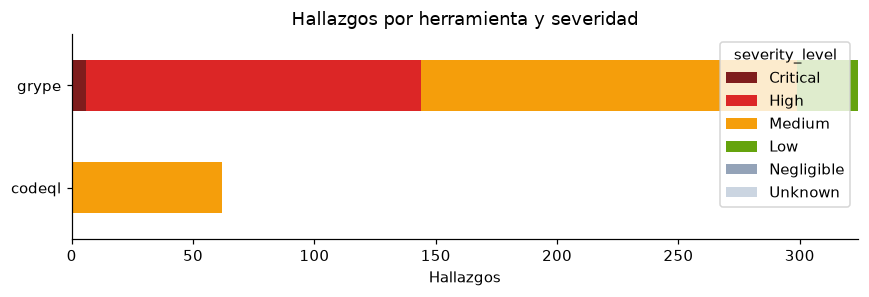

In [3]:
overview = (
    df.groupby(["source", "severity_level"]).size().unstack(fill_value=0)
    .reindex(columns=GRYPE_SEVERITY_ORDER, fill_value=0)
)
display(overview)

colors = {"Critical": "#7f1d1d", "High": "#dc2626", "Medium": "#f59e0b",
          "Low": "#65a30d", "Negligible": "#94a3b8", "Unknown": "#cbd5e1"}
ax = overview.plot.barh(stacked=True, color=[colors[c] for c in overview.columns], figsize=(8, 2.8))
ax.set_xlabel("Hallazgos"); ax.set_ylabel("")
ax.set_title("Hallazgos por herramienta y severidad")
plt.tight_layout(); plt.show()
overview.to_csv(OUT / "severity_overview.csv")

## 3. CodeQL: tipos de vulnerabilidad en el código

Se cuenta cuántos hallazgos produce cada regla **y en cuántos repositorios aparece**.
Una regla frecuente en muchos repositorios es un patrón sistémico; una concentrada en uno solo es un problema local.

,findings,repos
vulnerability_id,,
py/url-redirection,27,4
py/flask-debug,24,3
py/weak-sensitive-data-hashing,3,2
py/path-injection,3,1
py/log-injection,1,1
py/overly-permissive-file,1,1
py/redos,1,1
py/reflective-xss,1,1
py/stack-trace-exposure,1,1


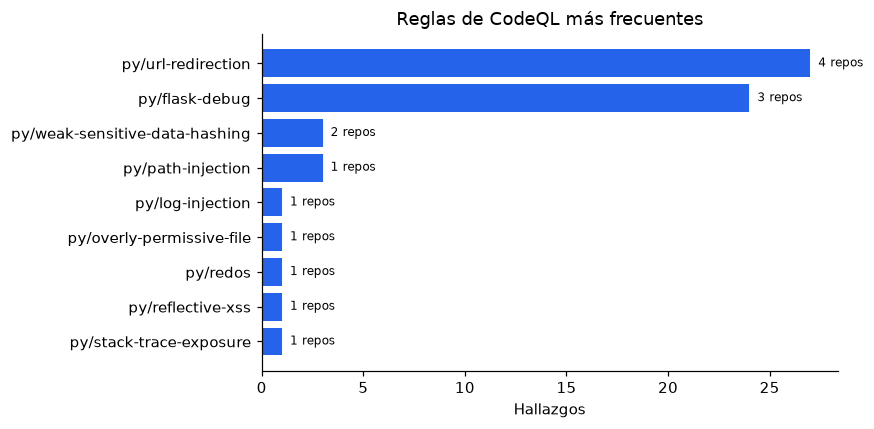

In [4]:
if codeql.empty:
    print("CodeQL no produjo hallazgos.")
    top_rules = pd.DataFrame(columns=["findings", "repos"])
else:
    top_rules = (
        codeql.groupby("vulnerability_id")
        .agg(findings=("title", "size"), repos=("repository", "nunique"))
        .sort_values(["findings", "repos"], ascending=False)
    )
    display(top_rules.head(10))
    top = top_rules.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top.index, top["findings"], color="#2563eb")
    for i, (f, r) in enumerate(zip(top["findings"], top["repos"])):
        ax.text(f, i, f"  {r} repos", va="center", fontsize=8)
    ax.set_xlabel("Hallazgos"); ax.set_title("Reglas de CodeQL más frecuentes")
    plt.tight_layout(); plt.show()
top_rules.to_csv(OUT / "codeql_rules.csv")

## 4. CodeQL: ¿el riesgo está en el código de producción?

Se clasifica cada hallazgo según la ruta del archivo (`source`, `tests`, `docs`, `examples`).
Los hallazgos en tests y ejemplos suelen ser menos relevantes que los del código que se distribuye.

severity_level,Medium
path_category,
examples,27
source,35


56% de los hallazgos de CodeQL están en código fuente (no tests/docs/ejemplos).


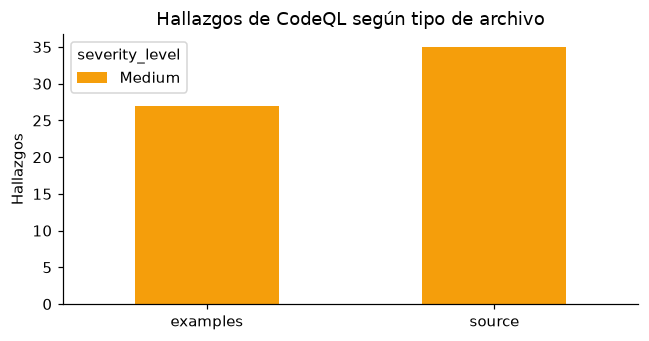

In [5]:
if not codeql.empty:
    paths = codeql["path_category"].value_counts()
    by_cat = pd.crosstab(codeql["path_category"], codeql["severity_level"]).reindex(
        columns=[c for c in GRYPE_SEVERITY_ORDER if c in codeql["severity_level"].unique()])
    display(by_cat)
    share_source = paths.get("source", 0) / len(codeql)
    print(f"{share_source:.0%} de los hallazgos de CodeQL están en código fuente (no tests/docs/ejemplos).")
    by_cat.plot.bar(stacked=True, color=[colors[c] for c in by_cat.columns], figsize=(6, 3.2))
    plt.ylabel("Hallazgos"); plt.xlabel(""); plt.xticks(rotation=0)
    plt.title("Hallazgos de CodeQL según tipo de archivo")
    plt.tight_layout(); plt.show()
    summary["codeql_source_share"] = round(float(share_source), 3)
    by_cat.to_csv(OUT / "codeql_path_categories.csv")

## 5. Concentración: ¿pocos repositorios acumulan los hallazgos?

Se usan los datos por repositorio (incluidos los que tienen **cero** hallazgos) y se mide la concentración con la cuota de los 3 principales y el coeficiente de Gini
(0 = reparto uniforme, 1 = todo en un solo repositorio).

,total,top3_share,gini,repos_with_zero
CodeQL,62.0,0.823,0.887,19.0
Grype,324.0,0.469,0.754,17.0


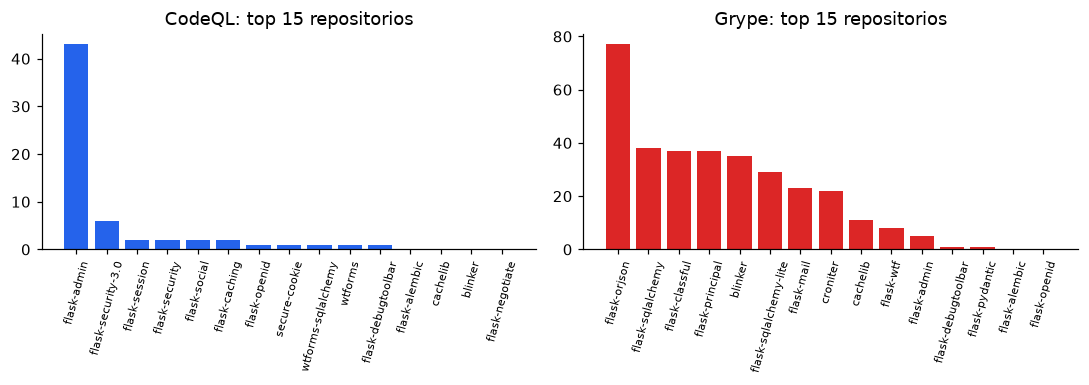

In [6]:
def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

conc = {}
for label, col in [("CodeQL", "codeql_findings"), ("Grype", "grype_vulnerabilities")]:
    values = repos[col].dropna()
    total = values.sum()
    top3 = values.sort_values(ascending=False).head(3).sum() / total if total else 0
    conc[label] = {"total": int(total), "top3_share": round(float(top3), 3),
                   "gini": round(gini(values), 3),
                   "repos_with_zero": int((values == 0).sum())}
conc_df = pd.DataFrame(conc).T
display(conc_df)
summary["concentration"] = conc

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (label, col) in zip(axes, [("CodeQL", "codeql_findings"), ("Grype", "grype_vulnerabilities")]):
    s = repos.set_index("short_name")[col].dropna().sort_values(ascending=False).head(15)
    ax.bar(s.index, s.values, color="#2563eb" if label == "CodeQL" else "#dc2626")
    ax.set_title(f"{label}: top 15 repositorios"); ax.tick_params(axis="x", rotation=75, labelsize=7)
plt.tight_layout(); plt.show()

## 6. Grype: dependencias vulnerables

Grype cuenta **coincidencias** (paquete × vulnerabilidad). Una misma CVE en varios paquetes o repositorios se cuenta varias veces,
por eso se comparan coincidencias y CVE distintas, y se mide qué parte tiene **corrección disponible** (`fix_versions`).

In [7]:
if grype.empty:
    print("Grype no produjo coincidencias.")
else:
    matches = len(grype)
    distinct_cves = grype["vulnerability_id"].nunique()
    fixable = grype["fixable"].mean()
    print(f"{matches} coincidencias | {distinct_cves} CVE distintas | {fixable:.0%} con versión corregida disponible")

    sev = grype.groupby("severity_level").agg(
        matches=("vulnerability_id", "size"),
        distinct_cves=("vulnerability_id", "nunique"),
        fixable_share=("fixable", "mean"),
    ).reindex(GRYPE_SEVERITY_ORDER).dropna(how="all")
    sev["fixable_share"] = (sev["fixable_share"] * 100).round(1)
    display(sev)
    summary["grype"] = {"matches": int(matches), "distinct_cves": int(distinct_cves),
                        "fixable_share": round(float(fixable), 3)}
    sev.to_csv(OUT / "grype_severity.csv")

324 coincidencias | 73 CVE distintas | 100% con versión corregida disponible


,matches,distinct_cves,fixable_share
severity_level,,,
Critical,6.0,1.0,100.0
High,138.0,31.0,100.0
Medium,155.0,34.0,100.0
Low,25.0,7.0,100.0


In [8]:
if not grype.empty:
    top_packages = (
        grype.groupby(["package", "package_version"])
        .agg(matches=("vulnerability_id", "size"),
             distinct_cves=("vulnerability_id", "nunique"),
             repos=("repository", "nunique"),
             worst=("severity_level", lambda s: min(s, key=GRYPE_SEVERITY_ORDER.index)),
             fixable=("fixable", "mean"))
        .sort_values(["repos", "matches"], ascending=False)
        .reset_index()
    )
    display(top_packages.head(10))
    systemic = top_packages[top_packages["repos"] >= 3]
    print(f"{len(systemic)} versiones de paquetes vulnerables aparecen en 3 o más repositorios (riesgo compartido).")
    summary["systemic_packages"] = int(len(systemic))
    top_packages.head(50).to_csv(OUT / "grype_top_packages.csv", index=False)

,package,package_version,matches,distinct_cves,repos,worst,fixable
0,urllib3,2.7.0,21,3,7,High,1.0
1,urllib3,2.6.3,30,5,6,High,1.0
2,requests,2.32.5,6,1,6,Medium,1.0
3,filelock,3.19.1,10,2,5,Medium,1.0
4,pytest,8.3.5,5,1,5,Medium,1.0
5,pytest,8.4.2,5,1,5,Medium,1.0
6,werkzeug,3.1.8,5,1,5,Medium,1.0
7,urllib3,2.2.3,32,8,4,High,1.0
8,virtualenv,21.3.3,16,4,4,High,1.0
9,werkzeug,3.0.6,16,4,4,Medium,1.0


16 versiones de paquetes vulnerables aparecen en 3 o más repositorios (riesgo compartido).


## 7. Relaciones: tamaño de dependencias, código y riesgo

- ¿Los repositorios con más componentes (SBOM) acumulan más vulnerabilidades?
- ¿Los repositorios con más hallazgos en el código también tienen más dependencias vulnerables?

Se usa correlación de Spearman (robusta a valores extremos). Con pocos repositorios, una correlación es un indicio, no una prueba.

,sbom_components,grype_vulnerabilities,codeql_findings
sbom_components,1.00,0.73,-0.18
grype_vulnerabilities,0.73,1.00,-0.42
codeql_findings,-0.18,-0.42,1.00


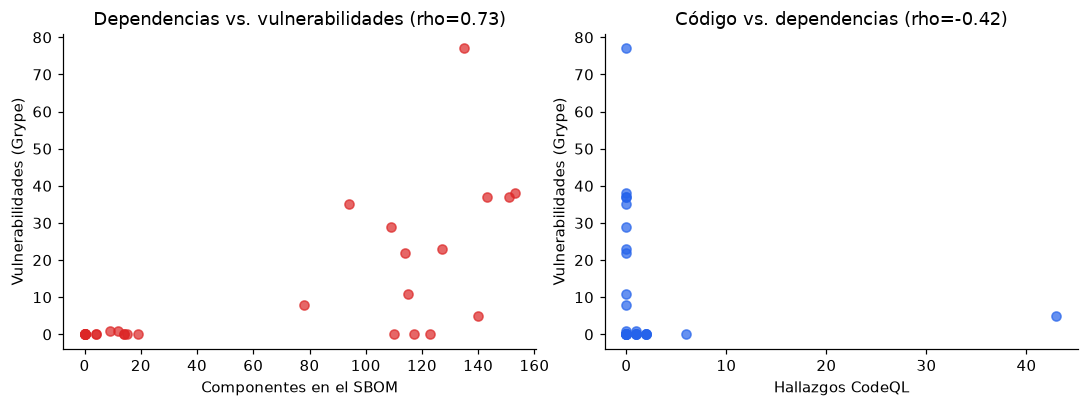

In [9]:
num = repos[["sbom_components", "grype_vulnerabilities", "codeql_findings"]].dropna()
corr = num.corr(method="spearman").round(2)
display(corr)
summary["spearman"] = {
    "components_vs_grype": float(corr.loc["sbom_components", "grype_vulnerabilities"]),
    "codeql_vs_grype": float(corr.loc["codeql_findings", "grype_vulnerabilities"]),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(num["sbom_components"], num["grype_vulnerabilities"], color="#dc2626", alpha=.7)
axes[0].set_xlabel("Componentes en el SBOM"); axes[0].set_ylabel("Vulnerabilidades (Grype)")
axes[0].set_title(f"Dependencias vs. vulnerabilidades (rho={corr.iloc[0, 1]})")
axes[1].scatter(num["codeql_findings"], num["grype_vulnerabilities"], color="#2563eb", alpha=.7)
axes[1].set_xlabel("Hallazgos CodeQL"); axes[1].set_ylabel("Vulnerabilidades (Grype)")
axes[1].set_title(f"Código vs. dependencias (rho={corr.iloc[1, 2]})")
plt.tight_layout(); plt.show()

## 8. Ranking de riesgo por repositorio

Puntaje **explícito y reproducible** (los pesos son una decisión de diseño, no una medida oficial):

- Grype: Critical=10, High=5, Medium=2, Low=1
- CodeQL (solo código fuente): error/High=5, warning/Medium=2, note/Low=1

,short_name,status,sbom_components,score_deps,score_code,score_total
repository,,,,,,
pallets-eco/flask-orjson,flask-orjson,analyzed,135,250,0.0,250.0
pallets-eco/flask-sqlalchemy,flask-sqlalchemy,analyzed,153,127,0.0,127.0
pallets-eco/flask-principal,flask-principal,analyzed,143,125,0.0,125.0
pallets-eco/flask-classful,flask-classful,analyzed,151,117,0.0,117.0
pallets-eco/blinker,blinker,analyzed,94,109,0.0,109.0
pallets-eco/flask-sqlalchemy-lite,flask-sqlalchemy-lite,analyzed,109,95,0.0,95.0
pallets-eco/flask-mail,flask-mail,analyzed,127,87,0.0,87.0
pallets-eco/croniter,croniter,analyzed,114,83,0.0,83.0
pallets-eco/flask-admin,flask-admin,analyzed,140,16,40.0,56.0


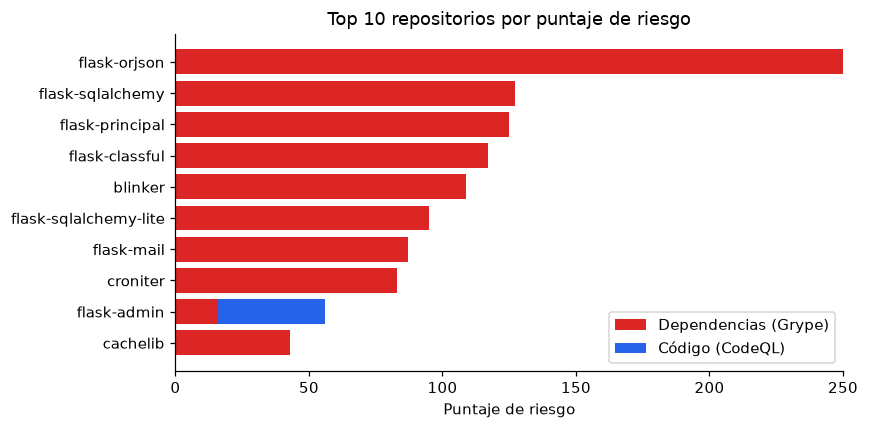

Correlación (Spearman) entre riesgo en dependencias y riesgo en código: -0.33


In [10]:
W_GRYPE = {"grype_critical": 10, "grype_high": 5, "grype_medium": 2, "grype_low": 1}
W_CODEQL = {"High": 5, "Medium": 2, "Low": 1}

risk = repos.set_index("repository")[["short_name", "status", "sbom_components"]].copy()
risk["score_deps"] = sum(repos.set_index("repository")[c].fillna(0) * w for c, w in W_GRYPE.items())

src = codeql[codeql["path_category"] == "source"]
code_score = src["severity_level"].map(W_CODEQL).fillna(0).groupby(src["repository"]).sum()
risk["score_code"] = code_score.reindex(risk.index).fillna(0)
risk["score_total"] = risk["score_deps"] + risk["score_code"]
risk = risk.sort_values("score_total", ascending=False)
display(risk.head(10))

top = risk.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top["short_name"], top["score_deps"], color="#dc2626", label="Dependencias (Grype)")
ax.barh(top["short_name"], top["score_code"], left=top["score_deps"], color="#2563eb", label="Código (CodeQL)")
ax.set_xlabel("Puntaje de riesgo"); ax.set_title("Top 10 repositorios por puntaje de riesgo"); ax.legend()
plt.tight_layout(); plt.show()

rho = risk[["score_deps", "score_code"]].corr(method="spearman").iloc[0, 1]
print(f"Correlación (Spearman) entre riesgo en dependencias y riesgo en código: {rho:.2f}")
summary["risk_top3"] = risk.head(3).index.tolist()
summary["spearman"]["score_deps_vs_score_code"] = float(round(rho, 2))
risk.to_csv(OUT / "repo_risk_ranking.csv")

## 9. Hallazgos principales (generados desde los datos)

El texto de abajo se calcula con los resultados anteriores, así que se actualiza si se vuelve a ejecutar el Miner.
La interpretación final para el poster debe revisarse con los gráficos.

In [11]:
lines = []
c = summary["coverage"]
lines.append(f"Se analizaron {c['codeql_analyzed']} de {c['repositories']} repositorios con CodeQL y {c['grype_scanned']} con Grype.")
if "Grype" in conc:
    lines.append(f"Los 3 repositorios con más vulnerabilidades en dependencias concentran {conc['Grype']['top3_share']:.0%} del total (Gini={conc['Grype']['gini']}).")
if "CodeQL" in conc and conc["CodeQL"]["total"]:
    lines.append(f"Los 3 repositorios con más hallazgos de CodeQL concentran {conc['CodeQL']['top3_share']:.0%} del total; {conc['CodeQL']['repos_with_zero']} repositorios no tienen ninguno.")
if "codeql_source_share" in summary:
    lines.append(f"Solo {summary['codeql_source_share']:.0%} de los hallazgos de CodeQL están en código fuente; el resto está en tests, docs o ejemplos.")
if "grype" in summary:
    g = summary["grype"]
    lines.append(f"Grype reporta {g['matches']} coincidencias que corresponden a {g['distinct_cves']} CVE distintas; {g['fixable_share']:.0%} tiene versión corregida disponible.")
if summary.get("systemic_packages"):
    lines.append(f"{summary['systemic_packages']} versiones de paquetes vulnerables se repiten en 3 o más repositorios.")
lines.append(f"Repositorios con mayor puntaje de riesgo: {', '.join(summary['risk_top3'])}.")

summary["observations"] = lines
for line in lines:
    print("-", line)

(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False,
               default=lambda o: o.item() if hasattr(o, "item") else str(o)),
    encoding="utf-8")
print("\nExportado en", OUT)

- Se analizaron 30 de 30 repositorios con CodeQL y 30 con Grype.
- Los 3 repositorios con más vulnerabilidades en dependencias concentran 47% del total (Gini=0.754).
- Los 3 repositorios con más hallazgos de CodeQL concentran 82% del total; 19 repositorios no tienen ninguno.
- Solo 56% de los hallazgos de CodeQL están en código fuente; el resto está en tests, docs o ejemplos.
- Grype reporta 324 coincidencias que corresponden a 73 CVE distintas; 100% tiene versión corregida disponible.
- 16 versiones de paquetes vulnerables se repiten en 3 o más repositorios.
- Repositorios con mayor puntaje de riesgo: pallets-eco/flask-orjson, pallets-eco/flask-sqlalchemy, pallets-eco/flask-principal.

Exportado en /home/catalina/ICC610-P1/data/processed/analysis
